# Título: Perdendo dinheiro na bolsa de valores

- PET - Física
- Petiana: Ylana Karolina Santos Lopes
- Data: 10 de Abril de 2026

O objetivo deste `Notebook` é introduzir de forma prática a Econofísica, analisando o comportamento de uma ação real do mercado (Petrobras - PETR4). Vamos aplicar ferramentas inspiradas na física para limpar o gráfico de preços, separando as tendências mais fortes e consistentes das flutuações rápidas e caóticas que acontecem no dia a dia.

Ao longo do texto, trataremos o mercado financeiro como um sistema físico dinâmico. Mostraremos como pegar um gráfico complexo e quebrá-lo em ondas mais simples (usando um algoritmo chamado CEEMDAN), e como calcular a energia dessas ondas. Por fim, vamos usar uma Rede Neural do tipo Long Short Time Memory para ler esse comportamento ondulatório e tentar prever os próximos movimentos.

Tudo será construído passo a passo, de forma que não é necessário nenhum conhecimento prévio em economia ou mercado financeiro para acompanhar o raciocínio.

Com isso, o `Notebook` será organizado da seguinte forma:

    1. Introdução: O mercado como um sistema dinâmico;
    2. A Física do Sinal;
    3. Previsão com LSTM-HHT;
    4. Resultados e Limitações;
    5. Conclusão.

## Importando bibliotecas

In [9]:
import numpy as np
import pandas as pd
import yfinance as yf
from PyEMD import CEEMDAN
from scipy.signal import hilbert
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import torch
import torch.nn as nn
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_percentage_error, mean_squared_error


## Informações sobre as bibliotecas

In [12]:
%load_ext version_information
%version_information numpy, pandas, yfinance, PyEMD, scipy, matplotlib, torch, sklearn

Software,Version
Python,3.11.8 64bit [MSC v.1916 64 bit (AMD64)]
IPython,8.20.0
OS,Windows 10 10.0.26200 SP0
numpy,1.26.4
pandas,2.1.4
yfinance,1.2.0
PyEMD,1.9.0
scipy,1.17.1
matplotlib,3.8.0
torch,2.7.0+cpu


## 1. Introdução: O mercado como um sistema dinâmico


[*********************100%***********************]  1 of 1 completed


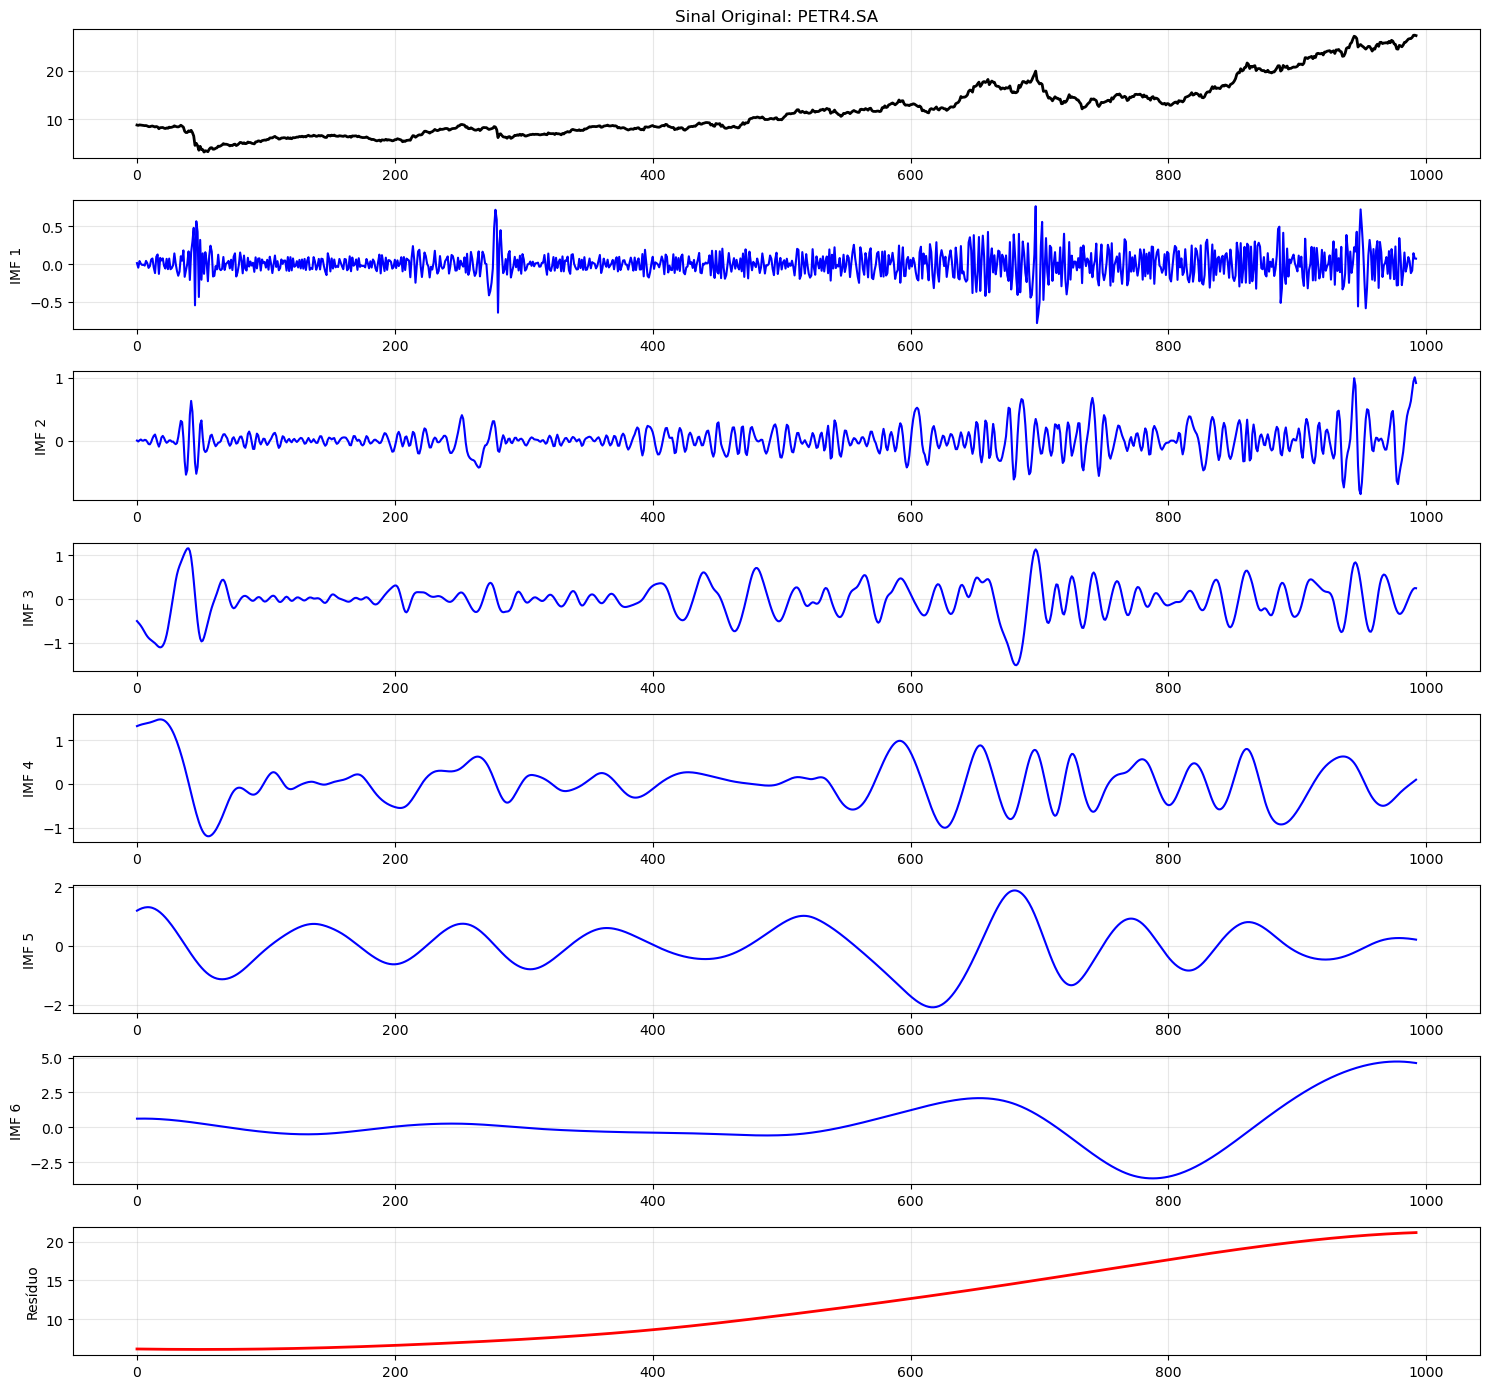

In [2]:
# 1. Obter e Limpar Dados (PETR4)
ticker = 'PETR4.SA'
df = yf.download(ticker, start='2020-01-01', end='2024-01-01')
prices = df['Close'].dropna().values.flatten().astype(np.float64)
t = np.arange(len(prices))

# 2. Decomposição CEEMDAN Robustecida
ceemdan = CEEMDAN(trials=100, epsilon=0.005)
imfs = ceemdan(prices, t)
num_imfs = imfs.shape[0]

# 3. Plotar Todas as IMFs e o Resíduo
plt.figure(figsize=(15, num_imfs * 2))
plt.subplot(num_imfs + 1, 1, 1)
plt.plot(t, prices, 'k', linewidth=2)
plt.title(f'Sinal Original: {ticker}')
plt.grid(True, alpha=0.3)

for i in range(num_imfs - 1):
    plt.subplot(num_imfs + 1, 1, i + 2)
    plt.plot(t, imfs[i], 'b')
    plt.ylabel(f'IMF {i+1}')
    plt.grid(True, alpha=0.3)

plt.subplot(num_imfs + 1, 1, num_imfs + 1)
plt.plot(t, imfs[-1], 'r', linewidth=2) # Última IMF é o Resíduo
plt.ylabel('Resíduo')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


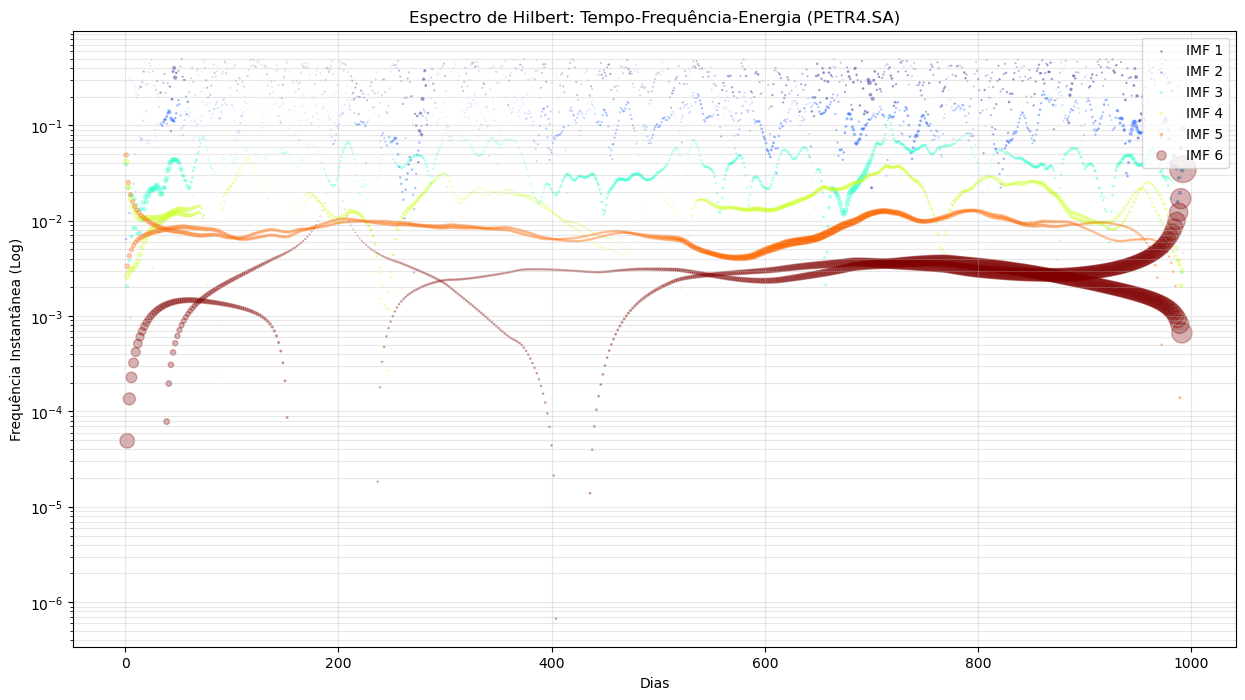

In [3]:
# ==============================================================================
# ANÁLISE CINEMÁTICA E FILTRAGEM FÍSICA (ESPECTRO DE HILBERT)
# ==============================================================================

# Configuração da primeira figura (Espectro 3D)
plt.figure(figsize=(15, 8))
colors = cm.jet(np.linspace(0, 1, num_imfs - 1))
mean_frequencies = []

# Loop ÚNICO: Calcula a Transformada, plota o Espectro e extrai as médias
for i in range(num_imfs - 1):
    # 1. Obtenção da Cinemática da Onda via Sinal Analítico Complexo
    analytic_signal = hilbert(imfs[i])
    amplitude = np.abs(analytic_signal)
    
    # Derivada da fase para encontrar a Frequência Instantânea
    phase = np.unwrap(np.angle(analytic_signal))
    frequency = np.diff(phase) / (2.0 * np.pi)
    
    # 2. Plot do Espectro de Hilbert (Tamanho do ponto = Energia da onda)
    energy = amplitude[1:]**2
    plt.scatter(t[1:], frequency, c=[colors[i]], s=energy * 5, alpha=0.3, label=f'IMF {i+1}')
    
    # 3. Guarda a Frequência Média para usar no Filtro Passa-Baixa
    valid_freqs = frequency[frequency > 0] # Remove ruído numérico espúrio
    if len(valid_freqs) > 0:
        mean_frequencies.append(np.mean(valid_freqs))
    else:
        mean_frequencies.append(0)

# Renderiza a Visualização 1 (O Mapa de Energia)
plt.yscale('log')
plt.title(f'Espectro de Hilbert: Tempo-Frequência-Energia ({ticker})')
plt.xlabel('Dias')
plt.ylabel('Frequência Instantânea (Log)')
plt.grid(True, which="both", ls="-", alpha=0.3)
plt.legend(loc='upper right', markerscale=0.5)
plt.show()




--- Frequências Fundamentais (Modos Normais) ---
IMF 1: Frequência Média = 0.2950 ciclos/dia
IMF 2: Frequência Média = 0.1221 ciclos/dia
IMF 3: Frequência Média = 0.0425 ciclos/dia
IMF 4: Frequência Média = 0.0174 ciclos/dia
IMF 5: Frequência Média = 0.0082 ciclos/dia
IMF 6: Frequência Média = 0.0036 ciclos/dia


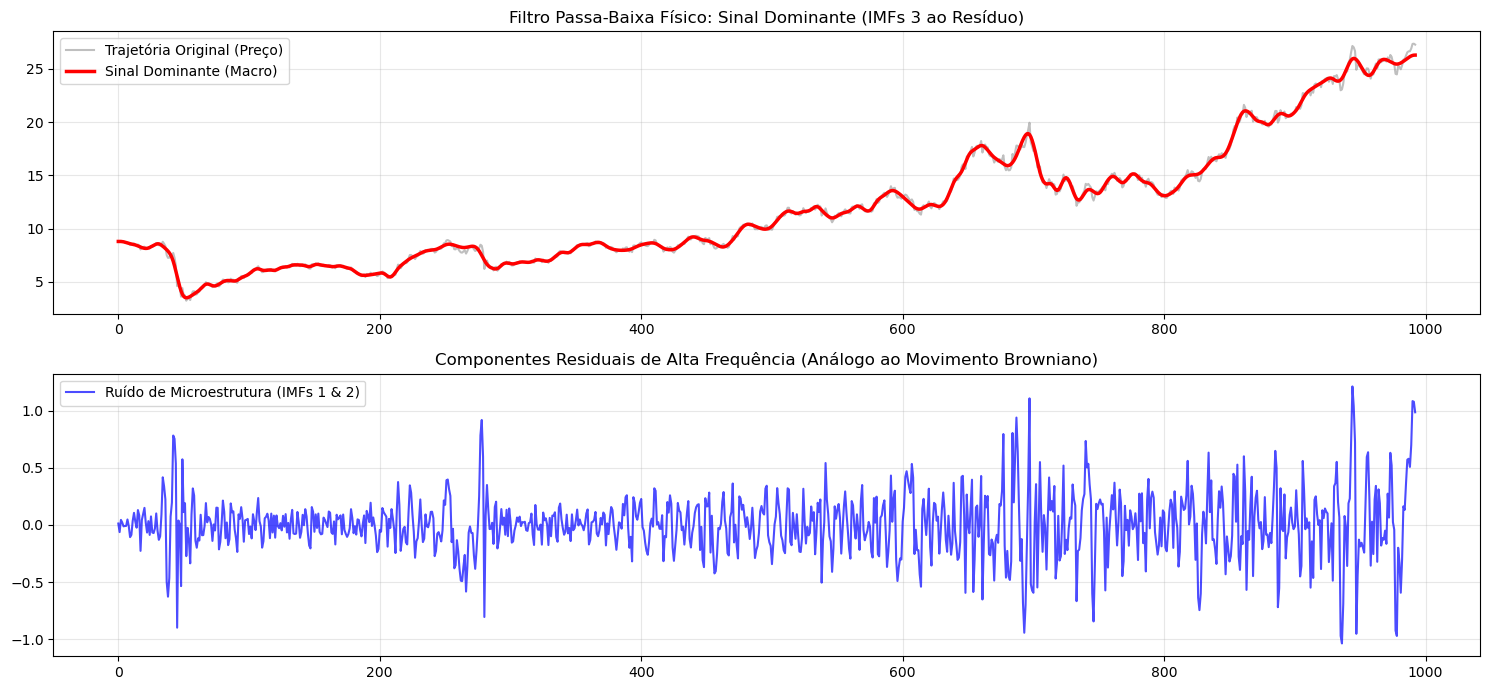

In [4]:
# ------------------------------------------------------------------------------
# FILTRAGEM: SEPARANDO O SINAL INERCIAL DA AGITAÇÃO TÉRMICA
# ------------------------------------------------------------------------------

print(f"\n--- Frequências Fundamentais (Modos Normais) ---")
for i, f in enumerate(mean_frequencies):
    print(f"IMF {i+1}: Frequência Média = {f:.4f} ciclos/dia")

# Regra de Ouro Quant: IMFs de altíssima frequência são ruído de microestrutura.
cut_off_index = 2 # IMFs 1 e 2 serão tratadas como "agitação térmica"

# Reconstrução linear (Princípio da Superposição)
sinal_dominante = np.sum(imfs[cut_off_index:], axis=0) # O momento inercial real
ruido_residual = np.sum(imfs[:cut_off_index], axis=0)  # O ruído descartado

# Renderiza a Visualização 2 (O Resultado do Filtro)
plt.figure(figsize=(15, 7))

# Plot Superior: O Sinal Limpo vs Original
plt.subplot(2, 1, 1)
plt.plot(t, prices, 'gray', alpha=0.5, label='Trajetória Original (Preço)')
plt.plot(t, sinal_dominante, 'r', linewidth=2.5, label='Sinal Dominante (Macro)')
plt.title(f'Filtro Passa-Baixa Físico: Sinal Dominante (IMFs {cut_off_index+1} ao Resíduo)')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot Inferior: O Ruído Descartado
plt.subplot(2, 1, 2)
plt.plot(t, ruido_residual, 'b', alpha=0.7, label='Ruído de Microestrutura (IMFs 1 & 2)')
plt.title('Componentes Residuais de Alta Frequência (Análogo ao Movimento Browniano)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

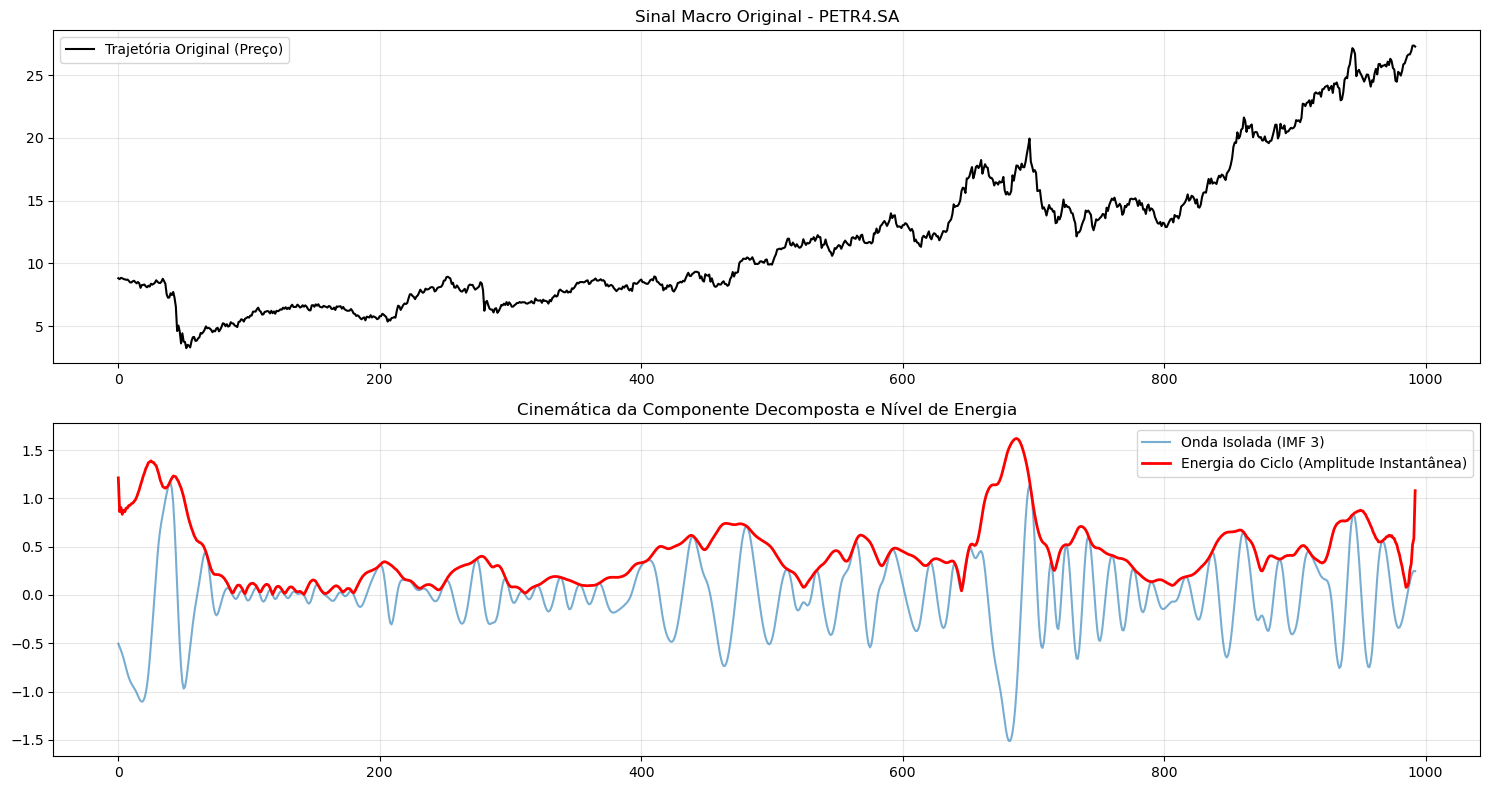

Dimensões do Tensor de Treino (X): torch.Size([782, 15, 1])
Dimensões do Tensor de Treino (y): torch.Size([782, 1])


In [5]:
# ==============================================================================
# ISOLANDO A ENERGIA DO CICLO (AMPLITUDE) PARA A REDE NEURAL
# ==============================================================================

# No bloco anterior, definimos que o ruído termina na IMF 2 (índices 0 e 1).
# Vamos pegar a primeira onda de "tendência macro" (IMF 3, índice 2) para modelar.
target_idx = 2 
imf_signal = imfs[target_idx]

# A Transformada de Hilbert nos dá o envelope da onda (sua Energia/Amplitude atual)
amplitude_instantanea = np.abs(hilbert(imf_signal))

# ------------------------------------------------------------------------------
# Visualização: A Onda Isolada e sua Energia Cinética
# ------------------------------------------------------------------------------
plt.figure(figsize=(15, 8))

# Plot Superior: Preço Original para referência
plt.subplot(2, 1, 1)
plt.plot(t, prices, label='Trajetória Original (Preço)', color='black')
plt.title(f'Sinal Macro Original - {ticker}')
plt.grid(True, alpha=0.3)
plt.legend()

# Plot Inferior: A onda pura e a curva de energia que a LSTM vai prever
plt.subplot(2, 1, 2)
plt.plot(t, imf_signal, label=f'Onda Isolada (IMF {target_idx + 1})', alpha=0.6)
plt.plot(t, amplitude_instantanea, label='Energia do Ciclo (Amplitude Instantânea)', color='red', linewidth=2)
plt.title('Cinemática da Componente Decomposta e Nível de Energia')
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

# ==============================================================================
# PREPARAÇÃO DOS TENSORES (MODELAGEM DA INÉRCIA NO PYTORCH)
# ==============================================================================

# 1. Normalização da Energia (Redes Neurais preferem valores entre 0 e 1)
scaler = MinMaxScaler()
scaled_amp = scaler.fit_transform(amplitude_instantanea.reshape(-1, 1))

# 2. Janela Deslizante (Lookback): A "memória" da inércia
lookback = 15
X, y = [], []

for i in range(len(scaled_amp) - lookback):
    X.append(scaled_amp[i:i+lookback]) # Pega 15 dias de energia passados
    y.append(scaled_amp[i+lookback])   # O alvo é a energia do dia 16

# 3. Conversão para Tensores do PyTorch
X = torch.tensor(np.array(X), dtype=torch.float32)
y = torch.tensor(np.array(y), dtype=torch.float32)

# 4. Split de Treino/Teste (80% para aprender a inércia, 20% para validar)
split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

print(f"Dimensões do Tensor de Treino (X): {X_train.shape}")
print(f"Dimensões do Tensor de Treino (y): {y_train.shape}")

In [25]:

# 1. Coleta de Dados Dupla
tickers = ['PETR4.SA', 'BZ=F'] # PETR4 e Brent Crude Oil
data = yf.download(tickers, start='2020-01-01', end='2024-01-01')['Close'].dropna()

# 2. Processamento HHT para ambos
ceemdan = CEEMDAN()
def get_clean_amp(series, target_imf=2):
    imfs = ceemdan(series.values.flatten())
    # Extraímos a amplitude da IMF escolhida
    return np.abs(hilbert(imfs[target_imf]))

amp_petr = get_clean_amp(data['PETR4.SA'])
amp_brent = get_clean_amp(data['BZ=F'])

# 3. Preparação Multivariada (X agora tem 2 colunas)
scaler = MinMaxScaler()
# Empilhamos as duas amplitudes como colunas
input_data = np.column_stack((amp_petr, amp_brent))
scaled_data = scaler.fit_transform(input_data)

lookback = 15
X, y = [], []
for i in range(len(scaled_data) - lookback):
    X.append(scaled_data[i:i+lookback, :]) # Todas as colunas (PETR e Brent)
    y.append(scaled_data[i+lookback, 0])    # Queremos prever apenas a PETR (coluna 0)

X = torch.tensor(np.array(X), dtype=torch.float32)
y = torch.tensor(np.array(y), dtype=torch.float32).view(-1, 1)

# 4. Ajuste na Arquitetura para Input_Size = 2
class MultiHHT_LSTM(nn.Module):
    def __init__(self, input_size=2, hidden_size=64):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, batch_first=True)
        self.linear = nn.Linear(hidden_size, 1)
        
    def forward(self, x):
        out, _ = self.lstm(x)
        return self.linear(out[:, -1, :])

model = MultiHHT_LSTM()
optimizer = torch.optim.Adam(model.parameters(), lr=0.005)
# ... (Treinamento igual ao bloco anterior) ...

[*********************100%***********************]  2 of 2 completed


[*********************100%***********************]  1 of 1 completed


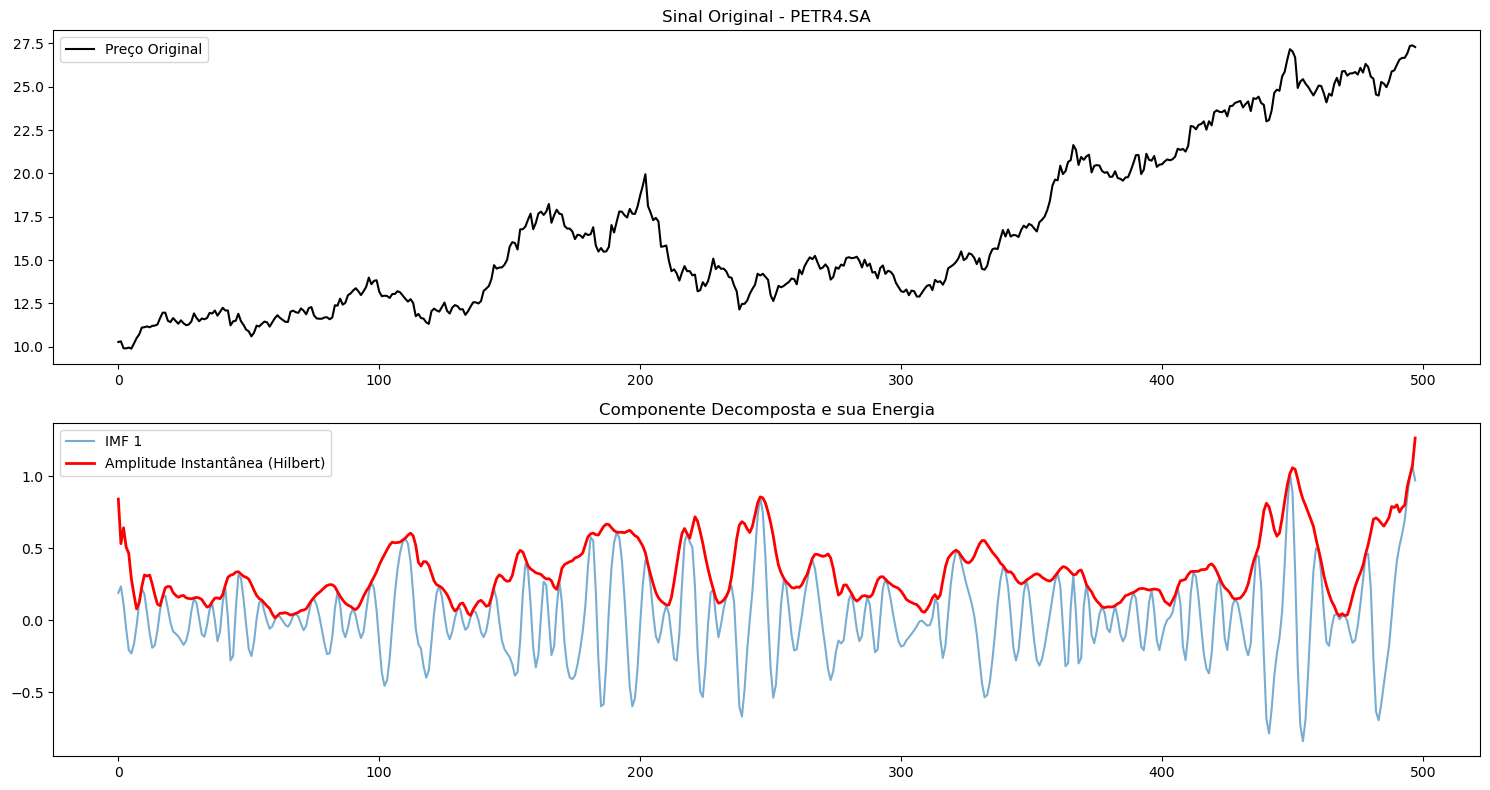

In [21]:


# 1. Download e Limpeza Estrita
ticker = 'PETR4.SA'
df = yf.download(ticker, start='2022-01-01', end='2024-01-01')

# IMPORTANTE: Remover NaNs e garantir que seja um array 1D float64
prices = df['Close'].dropna().values.flatten().astype(np.float64)

# Criar um eixo de tempo explícito com o mesmo tamanho do sinal
t = np.linspace(0, len(prices), len(prices))

# 2. Configurar e Rodar CEEMDAN
# Adicionamos epsilon e trials para estabilidade numérica
ceemdan = CEEMDAN(trials=50, epsilon=0.005)
imfs = ceemdan(prices, t) # Passamos o sinal e o eixo de tempo explicitamente

# 3. Escolha da IMF e Cálculo da Amplitude
target_idx = 1 
imf_signal = imfs[target_idx]
amplitude_instantanea = np.abs(hilbert(imf_signal))

# Visualização
plt.figure(figsize=(15, 8))
plt.subplot(2, 1, 1)
plt.plot(prices, label='Preço Original', color='black')
plt.title(f'Sinal Original - {ticker}')
plt.legend()

plt.subplot(2, 1, 2)
plt.plot(imf_signal, label=f'IMF {target_idx}', alpha=0.6)
plt.plot(amplitude_instantanea, label='Amplitude Instantânea (Hilbert)', color='red', linewidth=2)
plt.title('Componente Decomposta e sua Energia')
plt.legend()
plt.tight_layout()
plt.show()

Epoch [10/60], Loss: 0.031496
Epoch [20/60], Loss: 0.008902
Epoch [30/60], Loss: 0.003345
Epoch [40/60], Loss: 0.001812
Epoch [50/60], Loss: 0.001302
Epoch [60/60], Loss: 0.000936


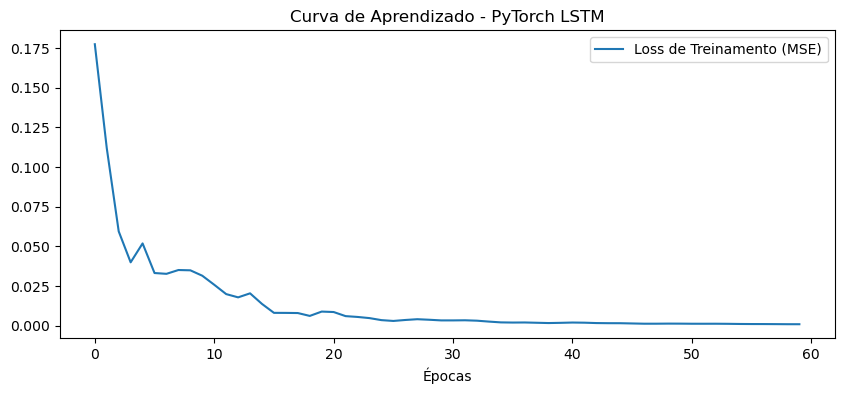

In [6]:


# 1. Preparação dos Dados
scaler = MinMaxScaler()
scaled_amp = scaler.fit_transform(amplitude_instantanea.reshape(-1, 1))

lookback = 15
X, y = [], []
for i in range(len(scaled_amp) - lookback):
    X.append(scaled_amp[i:i+lookback])
    y.append(scaled_amp[i+lookback])

X = torch.tensor(np.array(X), dtype=torch.float32)
y = torch.tensor(np.array(y), dtype=torch.float32)

# Split Treino/Teste (80/20)
split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

# 2. Definição da Arquitetura LSTM
class HHT_LSTM(nn.Module):
    def __init__(self, input_size=1, hidden_size=50, num_layers=1):
        super(HHT_LSTM, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.linear = nn.Linear(hidden_size, 1)
        
    def forward(self, x):
        out, _ = self.lstm(x)
        out = self.linear(out[:, -1, :]) # Pega apenas o último time-step
        return out

model = HHT_LSTM()
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

# 3. Loop de Treinamento
epochs = 60
losses = []

model.train()
for epoch in range(epochs):
    optimizer.zero_grad()
    outputs = model(X_train)
    loss = criterion(outputs, y_train)
    loss.backward()
    optimizer.step()
    losses.append(loss.item())
    if (epoch+1) % 10 == 0:
        print(f'Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.6f}')

# Visualização do Aprendizado
plt.figure(figsize=(10, 4))
plt.plot(losses, label='Loss de Treinamento (MSE)')
plt.title('Curva de Aprendizado - PyTorch LSTM')
plt.xlabel('Épocas')
plt.legend()
plt.show()

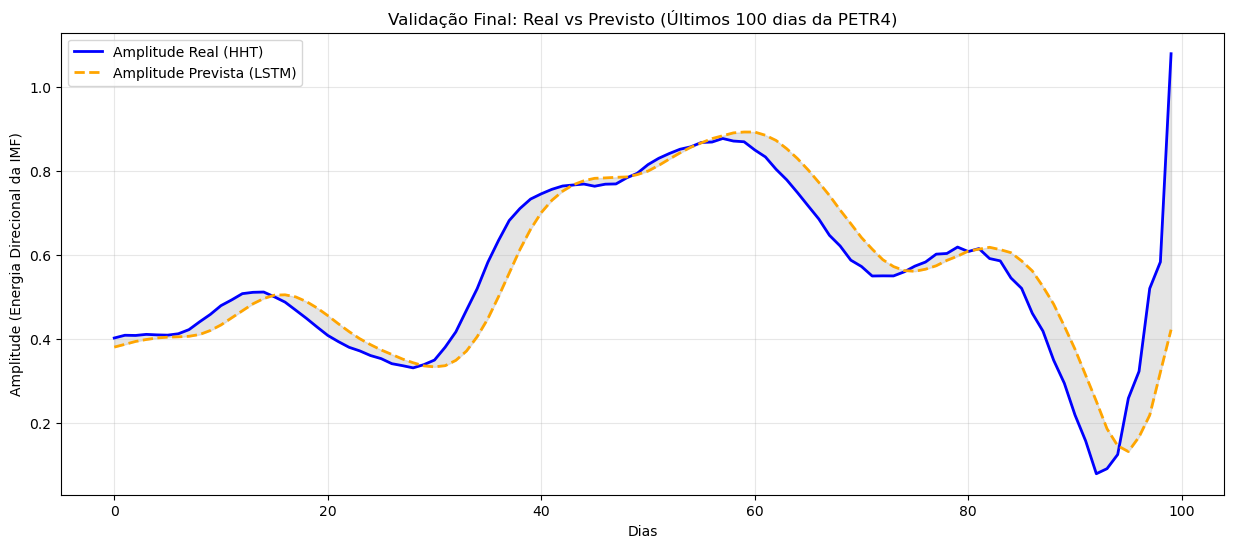

--- Performance do Modelo HHT-LSTM (Dados Não Vistos) ---
Erro Médio Quadrático (RMSE): 0.0769
Erro Percentual Absoluto (MAPE): 12.43%


In [10]:
# 1. Colocar o modelo em modo de avaliação (desativa Dropouts, congela pesos)
model.eval()

# 2. Realizar a predição sem calcular gradientes
with torch.no_grad():
    # Previsão apenas no conjunto de TESTE para as métricas matemáticas
    test_predictions_scaled = model(X_test).numpy()
    
    # Previsão em TODO o conjunto X para o gráfico contínuo
    all_predictions_scaled = model(X).numpy()

# 3. Inverter a escala para voltar aos valores originais de amplitude (Energia)
test_predictions = scaler.inverse_transform(test_predictions_scaled)
real_test = scaler.inverse_transform(y_test.numpy())

all_predictions = scaler.inverse_transform(all_predictions_scaled)
real_all = scaler.inverse_transform(y.numpy())

# 4. Cálculo das métricas de erro (ESTRITAMENTE NO CONJUNTO DE TESTE)
rmse = np.sqrt(mean_squared_error(real_test, test_predictions))
mape = mean_absolute_percentage_error(real_test, test_predictions) * 100

# 5. Visualização do Resultado (Focando nos últimos 100 dias - Região não vista)
plt.figure(figsize=(15, 6))

# Pegamos os últimos 100 dias do conjunto completo para plotar
plt.plot(real_all[-100:], label='Amplitude Real (HHT)', color='blue', linewidth=2)
plt.plot(all_predictions[-100:], label='Amplitude Prevista (LSTM)', color='orange', linestyle='--', linewidth=2)

# Destacar a diferença (Erro) visualmente
plt.fill_between(range(100), real_all[-100:].flatten(), all_predictions[-100:].flatten(), color='gray', alpha=0.2)

plt.title(f'Validação Final: Real vs Previsto (Últimos 100 dias da PETR4)')
plt.xlabel('Dias')
plt.ylabel('Amplitude (Energia Direcional da IMF)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 6. Diagnóstico do Modelo
print(f"--- Performance do Modelo HHT-LSTM (Dados Não Vistos) ---")
print(f"Erro Médio Quadrático (RMSE): {rmse:.4f}")
print(f"Erro Percentual Absoluto (MAPE): {mape:.2f}%")


--- Diagnóstico Físico do Mercado (Sinal Quant) ---
SINAL: Expansão de Energia. A inércia da tendência atual está ganhando força.


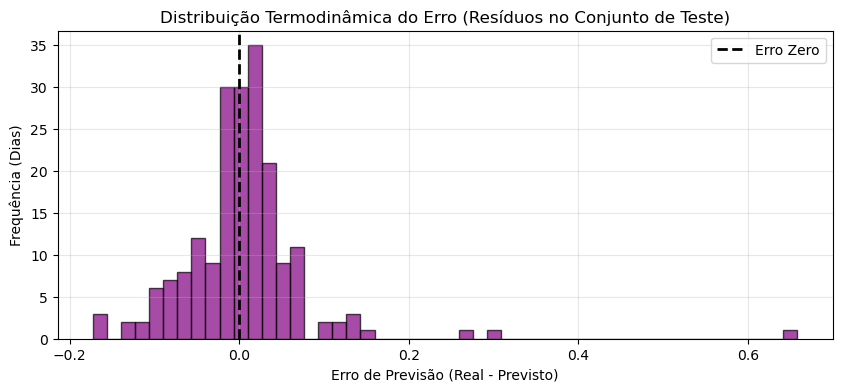

In [11]:
# ==============================================================================
# BLOCO D: APLICAÇÃO QUANT E DIAGNÓSTICO ESTATÍSTICO
# ==============================================================================

# 1. Diagnóstico de Momentum (Avaliando a Derivada da Energia)
amp_hoje = all_predictions[-2][0]   # Penúltimo dia da nossa série
amp_amanha = all_predictions[-1][0] # Último dia (previsão mais recente)

print(f"\n--- Diagnóstico Físico do Mercado (Sinal Quant) ---")
if amp_amanha > amp_hoje:
    print("SINAL: Expansão de Energia. A inércia da tendência atual está ganhando força.")
else:
    print("SINAL: Exaustão de Ciclo. A onda está perdendo energia (possível reversão).")

# 2. Visualização da Termodinâmica do Erro (Resíduos)
# Calculamos os resíduos APENAS nos dados não vistos (Teste) para rigor científico
residuals = real_test - test_predictions

plt.figure(figsize=(10, 4))
plt.hist(residuals, bins=50, color='purple', alpha=0.7, edgecolor='black')
plt.axvline(0, color='black', linestyle='dashed', linewidth=2, label='Erro Zero') # Linha central
plt.title('Distribuição Termodinâmica do Erro (Resíduos no Conjunto de Teste)')
plt.xlabel('Erro de Previsão (Real - Previsto)')
plt.ylabel('Frequência (Dias)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()